# LASSO Regression In-Class Exercise

In this exercise, we will see how to use LASSO for pitch detection and noise removal in audio.

We load the following packages.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

## Load the Data

The data is taken from a sample of about 20 ms of audio from a viola.  I have already pre-processed the data.  You can load it with the following command.  The value `t` is the time (in seconds) and `y` is the sample of audio (this is a mono recording).  Noise has been artificially added to the sample.

In [2]:
fn_src = 'https://raw.githubusercontent.com/sdrangan/introml/master/unit05_lasso/viola_sample.p'
fn_dst = 'viola_sample.p'

import os
from six.moves import urllib

if os.path.isfile(fn_dst):
    print('File %s is already downloaded' % fn_dst)
else:        
    urllib.request.urlretrieve(fn_src, fn_dst)
    print('File %s downloaded' % fn_dst)

with open(fn_dst,'rb') as fp:
    t,y = pickle.load(fp)

File viola_sample.p is already downloaded


Plot the data `y` vs. `t`.  

Text(0, 0.5, 'y')

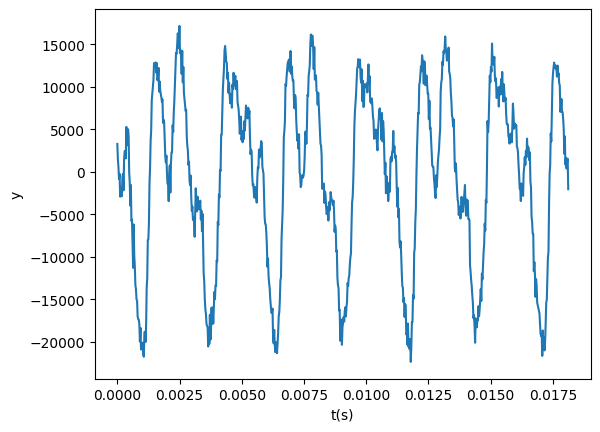

In [3]:
# TODO
plt.plot(t,y)
plt.xlabel('t(s)')
plt.ylabel('y')

In [4]:
len(y)

800

In [5]:
len(t)

800

## Creating Features for a Sinusoidal Model

We will try to fit a model of the form:

    y[i] = \sum_j a[j]*sin(2*pi*freq[j]*t[i]) + b[j]*cos(2*pi*freq[j]*t[i])

That is, `y[i]` is a sum of sinusoids.  This is a common model for audio signals since an instrument, such as a viola, produces discrete tones.  

This model is non-linear in the frequency parameters.  So, instead of trying to find the frequencies, we will fix a large number of frequencies and then require that the coefficients `a[j]` and `b[j]` are mostly sparse.  

We will use the following vector of frequencies.  This vector includes frequencies on the muscial scale as well as frequencies between the musical notes.

In [6]:
freq = 55*2**(np.arange(5*96)/96)

In [7]:
freq

array([  55.        ,   55.39855267,   55.79999342,   56.20434318,
         56.61162302,   57.02185417,   57.43505803,   57.85125614,
         58.27047019,   58.69272204,   59.1180337 ,   59.54642734,
         59.9779253 ,   60.41255007,   60.85032431,   61.29127084,
         61.73541266,   62.18277291,   62.63337491,   63.08724217,
         63.54439833,   64.00486723,   64.46867289,   64.93583946,
         65.40639133,   65.880353  ,   66.35774919,   66.8386048 ,
         67.32294488,   67.81079469,   68.30217966,   68.79712541,
         69.29565774,   69.79780265,   70.3035863 ,   70.81303506,
         71.32617551,   71.84303438,   72.36363862,   72.88801537,
         73.41619198,   73.94819597,   74.48405508,   75.02379725,
         75.56745061,   76.11504351,   76.66660449,   77.22216231,
         77.78174593,   78.34538453,   78.91310748,   79.48494438,
         80.06092506,   80.64107952,   81.22543803,   81.81403103,
         82.40688923,   83.00404352,   83.60552503,   84.21136

In [8]:
freq.shape

(480,)

To fit the sinusoidal model, we will write a function to map the values `t` to 
the `sin` and `cos` features.  Finish the function `transform` that creates matrices:

    Xcos[i,j] = np.cos(2*np.pi*t[i]*freq[j])
    Xsin[i,j] = np.sin(2*np.pi*t[i]*freq[j])
    X = np.hstack((Xcos,Xsin))
    
So, if `freq` is length `d`, there will `2*d` features.  You can try to create the matrices using python broadcasting if you want to avoid a for loop.    

In [9]:
def transform(t,freq):
    # TODO
    # Xcos = ...
    # Xsin = ...ß
    ''' No broadcasting solution:

    nt = len(t)
    nfreq = len(freq)
    Xcos = np.zeros((nt,nfreq))
    Xsin = np.zeros((nt,nfreq))

    for i in range(nt):
        for j in range(nfreq):
            Xcos[i,j] = np.cos(2*np.pi*t[i]*freq[j])
            Xsin[i,j] = np.sin(2*np.pi*t[i]*freq[j])           
    '''


    Xcos = np.cos(2*np.pi*t[:,None]*freq[None,:])
    Xsin = np.sin(2*np.pi*t[:,None]*freq[None,:])

    # in compiled languages, let's say C, both the broadcasting and for-loop version would run in the same time
    # BUT BROADCASTING WILL RUN FASTER BECAUSE PYTHON IS INTERPRETTED (broadcasting is called vectorization)
    # SPEEDUP OF FACTOR OF 1000
    
    X = np.hstack((Xcos,Xsin)) # nt-by-(2*nfreq) matrix
    return X

Split the data `t` and `y` into training and test.  Use approximately 50% for each set.

In [10]:
from sklearn.model_selection import train_test_split

# TODO
# ttr, tts, ytr, yts = train_test_split(...)
ttr, tts, ytr, yts = train_test_split(t, y, test_size=0.5)

In [11]:
ttr.shape,tts.shape

((400,), (400,))

In [12]:
ytr.shape,yts.shape

((400,), (400,))

Transform the `ttr`, `tts` into `Xtr` and `Xts`.

In [13]:
# TODO
Xtr = transform(ttr,freq)
Xts = transform(tts,freq)

In [14]:
Xtr.shape, Xts.shape

((400, 960), (400, 960))

In [15]:
ytr.shape, yts.shape

((400,), (400,))

## Use LASSO to Find the Frequencies

We can now use LASSO regression to find the model
* Use LASSO regression with `alpha=500` to fit the model.  
* Find the R^2-score on the test data.
* Plot the predicted value of `y` for `t in [0,0.02]`.

In [16]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
''' Scaling not needed??
from sklearn.preprocessing import StandardScaler

xscal = StandardScaler()
yscal = StandardScaler()

Xtr1 = xscal.fit_transform(Xtr)
ytr1 = yscal.fit_transform(ytr[:,None]) # column vector ytr

Xts1 = xscal.transform(Xts)
yts1 = yscal.transform(yts[:,None])
'''

# # Scaling:
# from sklearn.preprocessing import StandardScaler

# xscal = StandardScaler()
# yscal = StandardScaler()

# Xtr1 = xscal.fit_transform(Xtr)
# ytr1 = yscal.fit_transform(ytr[:,None]) # column vector ytr

# Xts1 = xscal.transform(Xts)
# yts1 = yscal.transform(yts[:,None])

# alpha = 500

# regr = Lasso(alpha=alpha)
# regr.fit(Xtr1,ytr1)

# yhat_ts1 = regr.predict(Xts1)
# rsq = r2_score(yts1, yhat_ts1)

# TODO
# regr = Lasso(...)
regr = Lasso(alpha=500)
regr.fit(Xtr,ytr)
yhat_ts = regr.predict(Xts)
rsq = r2_score(yts, yhat_ts)

print('Test R^2= %f' % rsq)

Test R^2= 0.940264


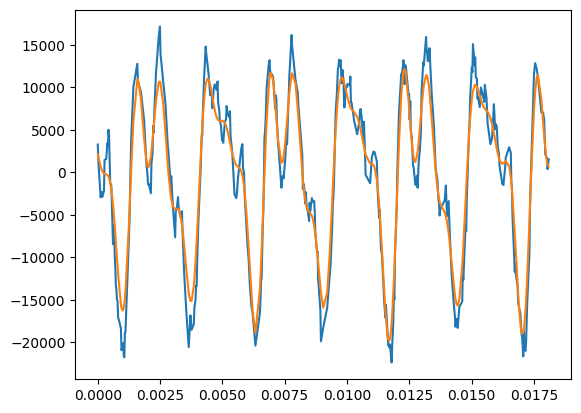

In [17]:
I = np.argsort(tts)
plt.plot(tts[I], yts[I])
plt.plot(tts[I], yhat_ts[I])

Recall that you can find the coefficient in the model via `w = regr.coef_`.  If `freq` has `d` terms, then `w` will have `2*d` terms.
* Split the coefficients `w` into `a` and `b`, the terms for the `cos` and `sin` features.
* Plot `a` and `b` using `plt.stem`.
* Which frequencies is dominant in this track?


[391.99543598 389.17531125 945.88853913 729.37977234 550.37700331
 546.41743731 194.58765562 136.60435933 177.15393651 167.21105007
 168.42273026 133.6772096  169.64319079 132.71549839 131.760706  ]
[1592.09766505 1284.44490757  961.694896    840.40800303  339.78233288
  175.21233394   50.92429578    0.            0.            0.
    0.            0.            0.            0.            0.        ]


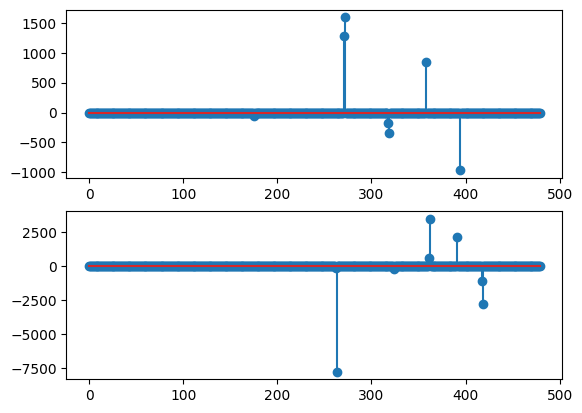

In [18]:
# TODO
w = regr.coef_
a = w[:len(freq)] # coefficients for cosine waves
b = w[len(freq):] # coefficients for sine waves
plt.subplot(2,1,1)
plt.stem(a)
plt.subplot(2,1,2)
plt.stem(b)

# find large freq(s)
I = np.argsort(np.abs(a))[::-1]
print(freq[I[:15]])
print(np.abs(a[I[:15]]))

Still have time...
* Find the optimal `alpha` using cross-validation

/Users/myron_zun_hao_weng/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.831e+06, tolerance: 4.171e+06
  model = cd_fast.enet_coordinate_descent(


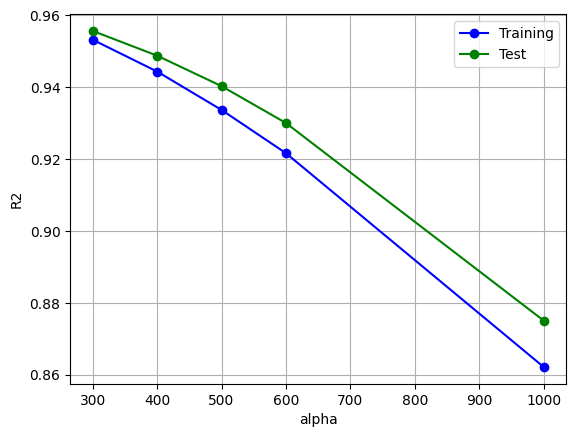

In [20]:
from sklearn.metrics import r2_score
alpha_test = [300, 400, 500, 600, 1000]
r2ts = []
r2tr = []

for al in alpha_test:
    reg = Lasso(alpha=al)
    reg.fit(Xtr, ytr)

    yhattr = reg.predict(Xtr)
    r2tr.append(r2_score(ytr, yhattr))

    yhatts = reg.predict(Xts)
    r2ts.append(r2_score(yts, yhatts))

plt.plot(alpha_test, r2tr,'bo-')
plt.plot(alpha_test, r2ts,'go-')
plt.xlabel('alpha')
plt.ylabel('R2')
plt.grid()
plt.legend(['Training', 'Test'], loc='upper right')